# Load land use data using LUloader

Loading raster landuse: LU.tif, MaskDN: None, Driver: TIF/8x
Loaded raster: pMOLU/SimExp\LU.tif[TIF/8x: (32, 32, 4)]


g:\OneDrive - The Chinese University of Hong Kong\pSO\LUloader.py:245: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


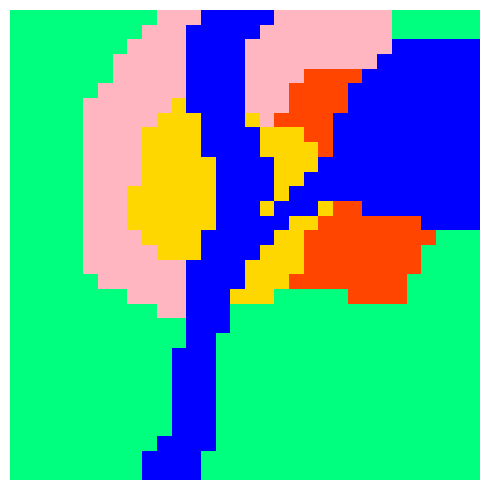

In [ ]:
from LUloader import LUloader
import matplotlib.pyplot as plt
cmap = ["blue", "gold", "lightpink", "orangered", "springgreen"]
LUx = LUloader(['W', 'U', 'R', 'I', 'G'], asProb=True, LUType='R', path='pMOLU/SimExp', cmap=cmap, LUname='LU.tif', driver='TIF', resample=8)
LUx.plot_LU()


# Load weights

In [2]:
import os
import numpy as np
try:
    import gdal
except ModuleNotFoundError:
    from osgeo import gdal
def read_tif_asXY(name, xy=None, path='.'):
    name = "%s/%s.tif" % (path, name)
    ds = gdal.Open(name)
    para = {'proj': ds.GetProjection(), 'tran': ds.GetGeoTransform(),
            'x': ds.RasterXSize, 'y': ds.RasterYSize}
    if xy is None:
        img = ds.ReadAsArray(0, 0, para['x'], para['y'])
    else:
        t = list(para['tran'])
        t[1] *= para['x'] * 1. / xy[0]
        t[5] *= para['y'] * 1. / xy[1]
        para['tran'] = t
        para['x'], para['y'] = xy
        img = ds.ReadAsArray(0, 0, buf_xsize=para['x'], buf_ysize=para['y'])
    return img, para

def load_W(path, xy):
    W = {}
    for _f in os.listdir(path):
        _n, _t = _f[:-4], _f[-4:]
        print("Loading weights: %s" % _f)
        if _t == '.csv':
            W[_n] = np.loadtxt("%s/%s.csv" % (path, _n), delimiter=',')
        elif (_t == '.tif'):
            W[_n], _ = read_tif_asXY(_n, xy=xy, path=path)
    return {w: W[w] / W[w].max() for w in W}

Ws = load_W('pMOLU/SimExp/Ws', LUx.var['LU'].shape[:2][::-1])

Loading weights: CCM.csv
Loading weights: eco.tif
Loading weights: gdp.tif
Loading weights: UUM.csv


# Define model (optimization problem)

In [3]:
from pSOmodel import OptProblem
import torch

def eta(p):
    return 1 - p * p / 3

def coversion(A, B, CCM):
    z1, z2 = CCM.shape
    A = torch.reshape(A, (-1, z1)).T
    B = torch.reshape(B, (-1, z2))
    ABm = torch.matmul(A, B) * CCM
    ABm = torch.sum(ABm, dim=-1)
    return torch.sum(ABm)

class SimProb(OptProblem):
    @property
    def con_sup(self):
        return [0.2]

    @property
    def n_obj(self):
        return [["Gdp", "Eco"], ["Cov"]]
    
    def calObj(self, DV):
        LU = DV['LU']
        p = torch.sum(LU, dim=(0, 1))     # calculate proportion: 1*C
        p /= torch.sum(p)                            # normalization

        w = eta(p)

        gdp = torch.sum(LU * self['W-UUM'][0] * w, axis=-1) * (1 - self['W-gdp'])
        eco = torch.sum(LU * self['W-UUM'][1], axis=-1) * (1 - self['W-eco'])

        Gdp = -torch.sum(gdp)
        Eco = -torch.sum(eco)

        Cov = coversion(LU, self['dvOrg-LU'], self['W-CCM'])
        return [torch.stack([Gdp, Eco]), torch.stack([Cov])]

# Initial normalization parameter (if need)

In [4]:
prob = SimProb(DV=dict(LU=LUx.var['LU']), dvSoft=dict(LU=10), dvMask=dict(LU=~LUx.var['R']), Ws=Ws)
prob.cuda()

opt = torch.optim.Adam(prob.parameters(), lr=1e-2)
prob.norm(opt, niter=10000, calMax=True)

Evaluating normalize parameters...


MAX Obj0_Gdp: 100%|██████████| 10000/10000 [00:40<00:00, 248.35it/s, loss=0.00]


Scale = 286.93975830078125


MAX Obj1_Eco: 100%|██████████| 10000/10000 [00:36<00:00, 271.80it/s, loss=-210.70]


Scale = 421.4051208496094


MAX Con0_Cov: 100%|██████████| 10000/10000 [00:34<00:00, 290.28it/s, loss=-679.40]

Scale = 679.4002685546875


# Optimization

MAX objs: 100%|██████████| 10000/10000 [00:38<00:00, 262.87it/s, loss=0.28]
g:\OneDrive - The Chinese University of Hong Kong\pSO\LUloader.py:245: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


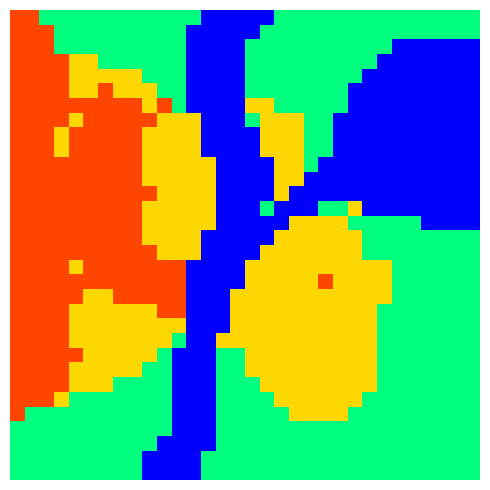

In [5]:
prob.optimize(lambda : torch.max(prob()[0]), opt, 'MAX objs', niter=10000, resetP=True)

pLU = prob.softMaskDV()['LU'].cpu().detach().numpy()
LUx.plot_pLU(pLU)
# LUx.plot_LU(LU)

plt.show()

# Continue optimization if not converged

MAX objs: 100%|██████████| 5000/5000 [00:18<00:00, 267.32it/s, loss=0.27]


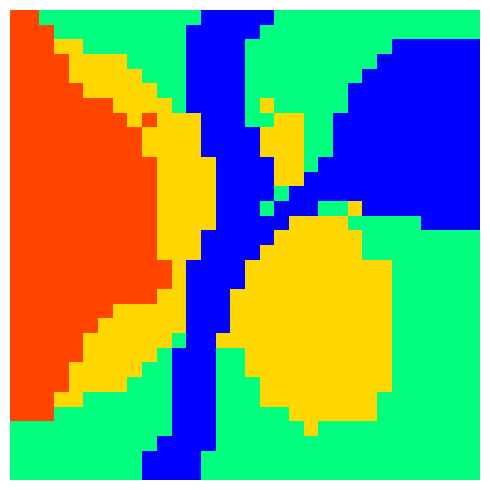

In [6]:
prob.optimize(lambda : torch.max(prob()[0]), opt, 'MAX objs', niter=5000, resetP=False)

pLU = prob.softMaskDV()['LU'].cpu().detach().numpy()
LUx.plot_pLU(pLU)
# LUx.plot_LU(LU)

plt.show()

In [7]:
prob()

(tensor([0.2750, 0.2750], device='cuda:0', grad_fn=<DivBackward0>),
 tensor([0.5182], device='cuda:0', grad_fn=<DivBackward0>))

In [8]:
prob.calObj(prob.softMaskDV())

[tensor([-208.0350,  -94.8317], device='cuda:0', grad_fn=<StackBackward>),
 tensor([352.0586], device='cuda:0', grad_fn=<StackBackward>)]